In [5]:
import os
import argparse
import time
from warnings import simplefilter
import gymnasium as gym
import numpy as np
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch

from RARL.DDQNSingle import DDQNSingle
from RARL.Trainer import Trainer
from RARL.config import dqnConfig, ceConfig
from RARL.utils import save_obj, load_obj
from utils.utils import plot_protagonist_adversary_actions, plot_RA_eval, plot_protagonist_adversary_values, PlotConfig
from gym_reachability import gym_reachability  # Custom Gym env.

# matplotlib.use('Agg')

simplefilter(action='ignore', category=FutureWarning)
timestr = time.strftime("%Y-%m-%d-%H_%M")

# == ARGS ==
parser = argparse.ArgumentParser()

# environment parameters
parser.add_argument(
    "-dt", "--doneType", help="when to raise done flag", default='TF',
    type=str
)
parser.add_argument(
    "-ct", "--costType", help="cost type", default='max', type=str
)
parser.add_argument(
    "-rnd", "--randomSeed", help="random seed", default=0, type=int
)
parser.add_argument(
    "-r", "--reward", help="when entering target set", default=-1, type=float
)
parser.add_argument(
    "-p", "--penalty", help="when entering failure set", default=1, type=float
)
parser.add_argument(
    "-s", "--scaling", help="scaling of ell/g", default=4, type=float
)

# training scheme
parser.add_argument(
    "-w", "--warmup", help="warmup Q-network", action="store_true"
)
parser.add_argument(
    "-wi", "--warmupIter", help="warmup iteration", default=2000, type=int
)
parser.add_argument(
    "-mu", "--maxUpdates", help="maximal #gradient updates", default=300000,
    type=int
)
parser.add_argument(
    "-ut", "--updateTimes", help="#hyper-param. steps", default=10, type=int
)
parser.add_argument(
    "-mc", "--memoryCapacity", help="memoryCapacity", default=10000, type=int
)
parser.add_argument(
    "-cp", "--checkPeriod", help="check period", default=20000, type=int
)

# NN hyper-parameters
parser.add_argument(
    "-a", "--annealing", help="gamma annealing", action="store_true"
)
parser.add_argument(
    "-arc", "--architecture", help="NN architecture", default=[100, 20],
    nargs="*", type=int
)
parser.add_argument(
    "-lr", "--learningRate", help="learning rate", default=1e-3, type=float
)
parser.add_argument(
    "-g", "--gamma", help="contraction coeff.", default=0.9999, type=float
)
parser.add_argument(
    "-act", "--actType", help="activation type", default='Tanh', type=str
)
parser.add_argument(
    "-nc", "--numCritic", help="number of critics", default=3, type=int
)

# RL type
parser.add_argument("-m", "--mode", help="mode", default='AARA', type=str)
parser.add_argument(
    "-tt", "--terminalType", help="terminal value", default='max', type=str
)

# file
parser.add_argument(
    "-st", "--showTime", help="show timestr", action="store_true"
)
parser.add_argument("-n", "--name", help="extra name", default='', type=str)
parser.add_argument(
    "-of", "--outFolder", help="output file", default='experiments', type=str
)
parser.add_argument(
    "-pf", "--plotFigure", help="plot figures", action="store_true"
)
parser.add_argument(
    "-sf", "--storeFigure", help="store figures", action="store_true"
)

args, unknown = parser.parse_known_args()
print(args)
print()

# == CONFIGURATION ==
env_name = "zermelo_show-v0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
maxUpdates = args.maxUpdates
updateTimes = args.updateTimes
updatePeriod = int(maxUpdates / updateTimes)
maxSteps = 250
storeFigure = args.storeFigure
plotFigure = args.plotFigure

fn = args.name + 'TF'
if args.showTime:
  fn = fn + '-' + timestr

outFolder = 'experiments/point-mass/SAC/AARA/TF-2026-03-28-23_14_59'
print(outFolder)
figureFolder = os.path.join(outFolder, 'figure')


if args.mode == 'RA':
  agentMode = 'RA'
  if args.annealing:
    GAMMA_END = 0.999999
    EPS_PERIOD = int(updatePeriod / 10)
    EPS_RESET_PERIOD = updatePeriod
  else:
    GAMMA_END = args.gamma
    EPS_PERIOD = updatePeriod
    EPS_RESET_PERIOD = maxUpdates

elif args.mode == 'AARA':
  agentMode = 'AARA'
  if args.annealing:
    GAMMA_END = 0.999999
    EPS_PERIOD = int(updatePeriod / 10)
    EPS_RESET_PERIOD = updatePeriod
  else:
    GAMMA_END = args.gamma
    EPS_PERIOD = updatePeriod
    EPS_RESET_PERIOD = maxUpdates

sample_inside_obs = False

# == Environment ==
print("\n== Environment Information ==")
env = gym.make(
    env_name, device=device,
    sample_inside_obs=sample_inside_obs, envType="basic"
)

stateDim = env.unwrapped.state.shape[0]
actionNum = env.unwrapped.action_space.n
action_list = np.arange(actionNum)
print(
    "State Dimension: {:d}, ActionSpace Dimension: {:d}".format(
        stateDim, actionNum
    )
)
print(f"Discrete Controls: {env.unwrapped.discrete_controls}")

env.unwrapped.set_costParam(args.penalty, args.reward, args.costType, args.scaling) # only needed for Lagrange
env.unwrapped.set_seed(args.randomSeed)


# == Agent CONFIG ==
print("\n== Agent Information ==")
PRO_CONFIG = dqnConfig(
    DEVICE=device, ENV_NAME=env_name, SEED=args.randomSeed,
    MAX_UPDATES=maxUpdates, MAX_EP_STEPS=maxSteps, BATCH_SIZE=64,
    MEMORY_CAPACITY=args.memoryCapacity, ARCHITECTURE=args.architecture,
    ACTIVATION=args.actType, GAMMA=args.gamma, GAMMA_PERIOD=updatePeriod,
    GAMMA_END=GAMMA_END, EPS_PERIOD=EPS_PERIOD, EPS_DECAY=0.7,
    EPS_RESET_PERIOD=EPS_RESET_PERIOD, LR_C=args.learningRate,
    LR_C_PERIOD=updatePeriod, LR_C_DECAY=0.8, MAX_MODEL=100
)

args.architecture = [120,20]
ADV_CONFIG = ceConfig(
    DEVICE=device, ENV_NAME=env_name, SEED=args.randomSeed,
    MAX_UPDATES=maxUpdates, MAX_EP_STEPS=maxSteps, BATCH_SIZE=64,
    MEMORY_CAPACITY=args.memoryCapacity, ARCHITECTURE=args.architecture,
    ACTIVATION=args.actType, GAMMA=args.gamma, GAMMA_PERIOD=updatePeriod,
    GAMMA_END=GAMMA_END, EPS_PERIOD=EPS_PERIOD, EPS_DECAY=0.7,
    EPS_RESET_PERIOD=EPS_RESET_PERIOD, LR_C=args.learningRate,
    LR_C_PERIOD=updatePeriod, LR_C_DECAY=0.8, MAX_MODEL=100, NUM_CRITICS=args.numCritic
)

# == TRAINER ==
trainer = Trainer(PRO_CONFIG)

# == PROTAGONIST AGENT ==
dimList = [stateDim] + PRO_CONFIG.ARCHITECTURE + [actionNum]
protagonist = DDQNSingle(
    PRO_CONFIG, actionNum, trainer.memory, dimList=dimList, mode=agentMode,
    terminalType=args.terminalType
)
print("We want to use: {}, and Agent uses: {}".format(device, protagonist.device))
print("Critic is using cuda: ", next(protagonist.Q_network.parameters()).is_cuda)


# == ADVERSARY AGENT ==
dimList = [stateDim + 1] + ADV_CONFIG.ARCHITECTURE + [actionNum] # +1 for sending the action into the adversary network 
adversary = DDQNSingle(
    ADV_CONFIG, actionNum, trainer.memory, dimList=dimList, mode=agentMode,
    terminalType=args.terminalType
)
print("We want to use: {}, and Agent uses: {}".format(device, adversary.device))
print("Critic is using cuda: ", next(adversary.Q_network.parameters()).is_cuda)

vmin = -1 * args.scaling
vmax = 1 * args.scaling
checkPeriod = args.checkPeriod

Namespace(doneType='TF', costType='max', randomSeed=0, reward=-1, penalty=1, scaling=4, warmup=False, warmupIter=2000, maxUpdates=300000, updateTimes=10, memoryCapacity=10000, checkPeriod=20000, annealing=False, architecture=[100, 20], learningRate=0.001, gamma=0.9999, actType='Tanh', numCritic=3, mode='AARA', terminalType='max', showTime=False, name='', outFolder='experiments', plotFigure=False, storeFigure=False)

experiments/point-mass/SAC/AARA/TF-2026-03-28-23_14_59

== Environment Information ==
Env: mode-AARA; doneType-toEnd; sample_inside_obs-False
State Dimension: 2, ActionSpace Dimension: 3
Discrete Controls: [[-1.   1.5]
 [ 0.   1.5]
 [ 1.   1.5]]

== Agent Information ==
ModuleList(
  (0): Linear(in_features=2, out_features=100, bias=True)
  (1): Tanh()
  (2): Linear(in_features=100, out_features=20, bias=True)
  (3): Tanh()
  (4): Linear(in_features=20, out_features=3, bias=True)
  (5): Identity()
)
DDQN: mode-AARA; terminalType-max
We want to use: cuda, and Agent uses: cud

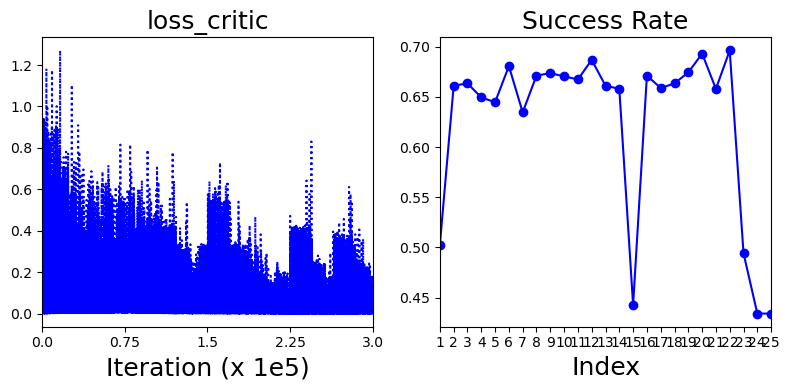

We pick model with success rate-0.696
  => Restore experiments/point-mass/SAC/AARA/TF-2026-03-28-23_14_59/pro_model/Q-440000.pth
Analytical Success Rate for Maximal Disturbances-0.598
Analytical Success Rate for No Disturbances-0.727
Best RA Success Rate with Adversarial Disturbances-0.425


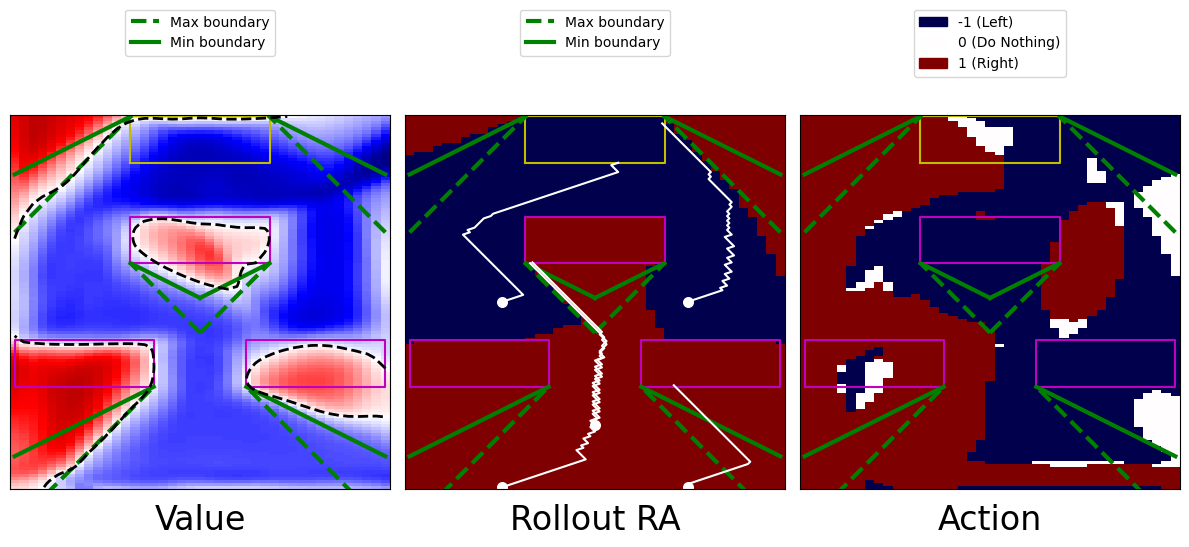

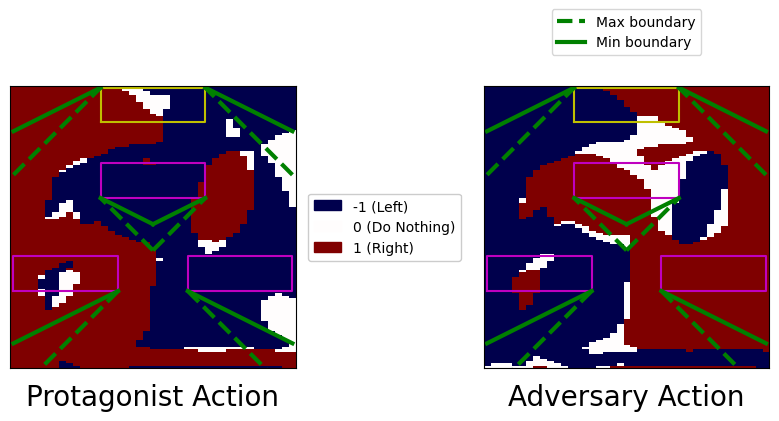

In [7]:
filePath = os.path.join(outFolder, 'train')
trainDict = load_obj(filePath)
trainRecords = trainDict['trainRecords']
trainProgress = trainDict['trainProgress']
resultMtx = trainDict['resultMtx']
actDistMtx = trainDict['actDistMtx']
disturbDistMtx = trainDict['disturbDistMtx']

plotFigure = True

if plotFigure or storeFigure:
  # = loss
  fig, axes = plt.subplots(1, 2, figsize=(8, 4))

  data = trainRecords
  ax = axes[0]
  ax.plot(data, 'b:')
  ax.set_xlabel('Iteration (x 1e5)', fontsize=18)
  ax.set_xticks(np.linspace(0, maxUpdates, 5))
  ax.set_xticklabels(np.linspace(0, maxUpdates, 5) / 1e5)
  ax.set_title('loss_critic', fontsize=18)
  ax.set_xlim(left=0, right=maxUpdates)

  data = trainProgress[:, 0]
  ax = axes[1]
  x = np.arange(data.shape[0]) + 1
  ax.plot(x, data, 'b-o')
  ax.set_xlabel('Index', fontsize=18)
  ax.set_xticks(x)
  # ax.set_xticklabels(np.arange(data.shape[0]) + 1)
  ax.set_title('Success Rate', fontsize=18)
  ax.set_xlim(left=1, right=data.shape[0])

  fig.tight_layout()
  if storeFigure:
    figurePath = os.path.join(figureFolder, 'train_loss_success.png')
    fig.savefig(figurePath)
  if plotFigure:
    plt.show()
    plt.pause(0.001)
  plt.close()

  # = value_rollout_action
  idx = np.argmax(trainProgress[:, 0]) + 1
  successRate = np.amax(trainProgress[:, 0])
  print('We pick model with success rate-{:.3f}'.format(successRate))
  protagonist.restore(idx * args.checkPeriod, outFolder, prefix="pro_")
  # adversary.restore(idx * args.checkPeriod, outFolder, prefix="adv_")

  nx = 41
  ny = 121
  xs = np.linspace(env.unwrapped.bounds[0, 0], env.unwrapped.bounds[0, 1], nx)
  ys = np.linspace(env.unwrapped.bounds[1, 0], env.unwrapped.bounds[1, 1], ny)

  resultMtx = np.empty((nx, ny), dtype=int)
  actDistMtx = np.empty((nx, ny), dtype=int)
  disturbDistMtx = np.empty((nx, ny), dtype=int)
  it = np.nditer(resultMtx, flags=['multi_index'])
  analytic_max_fail = 0
  analytic_min_fail = 0

  while not it.finished:
    idx = it.multi_index
    print(idx, end='\r')
    x = xs[idx[0]]
    y = ys[idx[1]]

    state = np.array([x, y])
    stateTensor = torch.FloatTensor(state).to(device).unsqueeze(0)
    action_index = protagonist.Q_network(stateTensor).min(dim=1)[1].cpu().item()
    # u = env.discrete_controls[action_index]
    # sa = torch.cat([stateTensor, torch.tensor([[action_index]], dtype=torch.float32).to(device)], dim=1)
    disturb_index = protagonist.Q_network(stateTensor).max(dim=1)[1].cpu().item()
    actDistMtx[idx] = action_index
    disturbDistMtx[idx] = disturb_index

    _, _, result = env.unwrapped.simulate_one_trajectory(
        protagonist.Q_network, adversary.Q_network, T=250, state=state
    )
    
    g_x = env.unwrapped.safety_margin(state)
    inside_max_diag = env.unwrapped.is_inside_diagonal_region(state)
    inside_min_diag = env.unwrapped.is_inside_diagonal_region(state, min=True)
    if g_x > 0:
      analytic_min_fail += 1
      analytic_max_fail += 1
    else:
      if inside_max_diag:
        analytic_max_fail += 1
      if inside_min_diag: 
        analytic_min_fail += 1

    resultMtx[idx] = result
    it.iternext()

  print('Analytical Success Rate for Maximal Disturbances-{:.3f}'.format(1 - analytic_max_fail/(nx*ny)))
  print('Analytical Success Rate for No Disturbances-{:.3f}'.format(1 - analytic_min_fail/(nx*ny)))
  print('Best RA Success Rate with Adversarial Disturbances-{:.3f}'.format((resultMtx == 1).sum()/(nx*ny)))

  cfg = PlotConfig(nx=nx, ny=ny, xs=xs, ys=ys, vmin=vmin, vmax=vmax, resultMtx=resultMtx, 
                   actDistMtx=actDistMtx, disturbDistMtx=disturbDistMtx, figureFolder=figureFolder, 
                   plotFigure=True, storeFigure=True, actionNum=actionNum)

  plot_RA_eval(env, protagonist, adversary, cfg)

  plot_protagonist_adversary_actions(env, protagonist, adversary, cfg)

  # plot_protagonist_adversary_values(env, protagonist, adversary, cfg)
  

**Test against adversarial**

Namespace(doneType='TF', costType='max', randomSeed=0, reward=-1, penalty=1, scaling=4, warmup=False, warmupIter=2000, maxUpdates=300000, updateTimes=10, memoryCapacity=10000, checkPeriod=20000, annealing=False, architecture=[100, 20], learningRate=0.001, gamma=0.9999, actType='Tanh', numCritic=3, mode='AARA', terminalType='max', showTime=False, name='', outFolder='experiments', plotFigure=False, storeFigure=False)

experiments/point-mass/SAC/AARA/TF-2026-03-30-09_19_46

== Environment Information ==
Env: mode-AARA; doneType-toEnd; sample_inside_obs-False
State Dimension: 2, ActionSpace Dimension: 3
Discrete Controls: [[-1.   1.5]
 [ 0.   1.5]
 [ 1.   1.5]]

== Agent Information ==
ModuleList(
  (0): Linear(in_features=2, out_features=100, bias=True)
  (1): Tanh()
  (2): Linear(in_features=100, out_features=20, bias=True)
  (3): Tanh()
  (4): Linear(in_features=20, out_features=3, bias=True)
  (5): Identity()
)
DDQN: mode-AARA; terminalType-max
We want to use: cuda, and Agent uses: cud

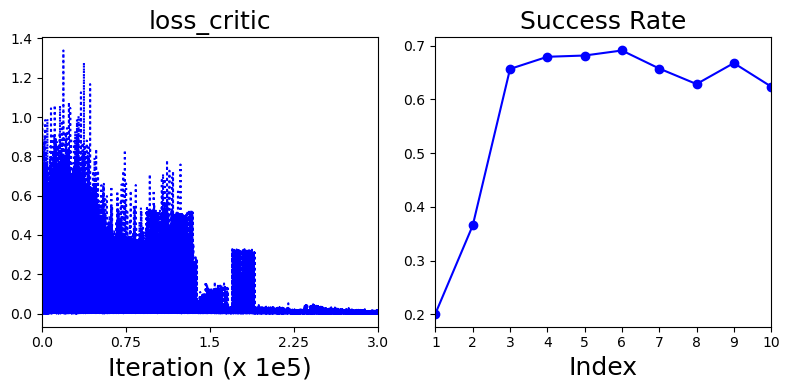

We pick model with success rate-0.691
  => Restore experiments/point-mass/SAC/AARA/TF-2026-03-30-09_19_46/pro_model/Q-120000.pth
Analytical Success Rate for Maximal Disturbances-0.614
Analytical Success Rate for No Disturbances-0.727
Best RA Success Rate with Adversarial Disturbances-0.613


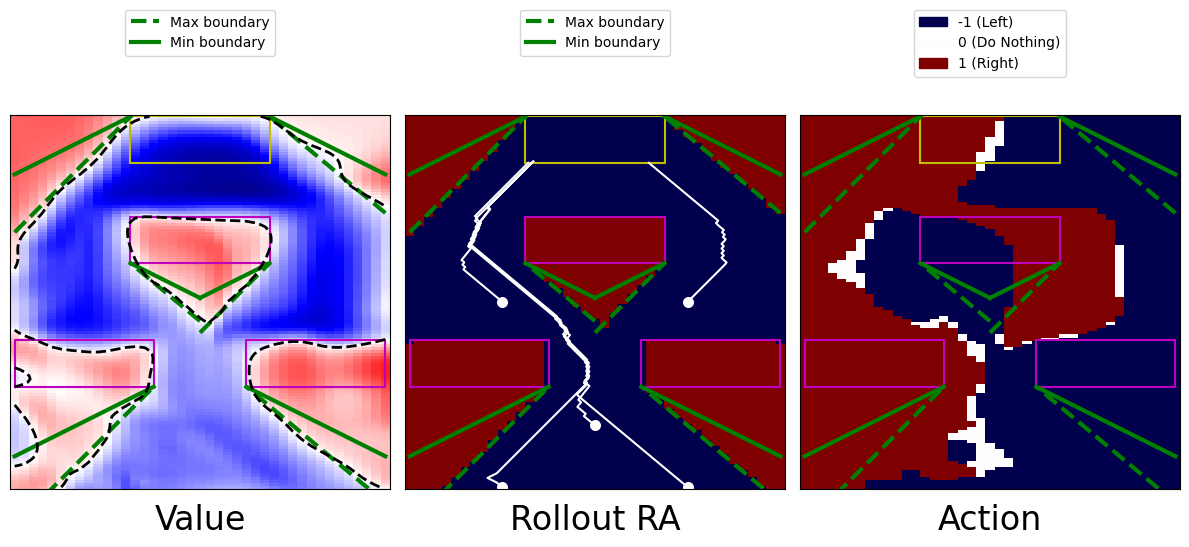

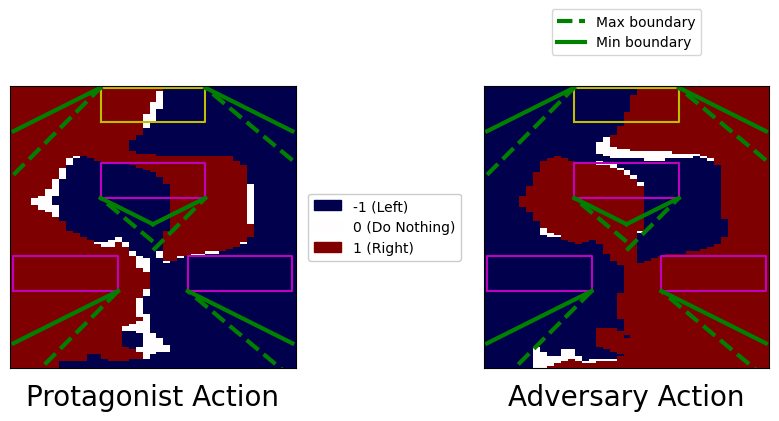

In [2]:
import os
import argparse
import time
from warnings import simplefilter
import gymnasium as gym
import numpy as np
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch

from RARL.DDQNSingle import DDQNSingle
from RARL.Trainer import Trainer
from RARL.config import dqnConfig, ceConfig
from RARL.utils import save_obj, load_obj
from utils.utils import plot_protagonist_adversary_actions, plot_RA_eval, plot_protagonist_adversary_values, PlotConfig
from gym_reachability import gym_reachability  # Custom Gym env.

# matplotlib.use('Agg')

simplefilter(action='ignore', category=FutureWarning)
timestr = time.strftime("%Y-%m-%d-%H_%M")

# == ARGS ==
parser = argparse.ArgumentParser()

# environment parameters
parser.add_argument(
    "-dt", "--doneType", help="when to raise done flag", default='TF',
    type=str
)
parser.add_argument(
    "-ct", "--costType", help="cost type", default='max', type=str
)
parser.add_argument(
    "-rnd", "--randomSeed", help="random seed", default=0, type=int
)
parser.add_argument(
    "-r", "--reward", help="when entering target set", default=-1, type=float
)
parser.add_argument(
    "-p", "--penalty", help="when entering failure set", default=1, type=float
)
parser.add_argument(
    "-s", "--scaling", help="scaling of ell/g", default=4, type=float
)

# training scheme
parser.add_argument(
    "-w", "--warmup", help="warmup Q-network", action="store_true"
)
parser.add_argument(
    "-wi", "--warmupIter", help="warmup iteration", default=2000, type=int
)
parser.add_argument(
    "-mu", "--maxUpdates", help="maximal #gradient updates", default=300000,
    type=int
)
parser.add_argument(
    "-ut", "--updateTimes", help="#hyper-param. steps", default=10, type=int
)
parser.add_argument(
    "-mc", "--memoryCapacity", help="memoryCapacity", default=10000, type=int
)
parser.add_argument(
    "-cp", "--checkPeriod", help="check period", default=20000, type=int
)

# NN hyper-parameters
parser.add_argument(
    "-a", "--annealing", help="gamma annealing", action="store_true"
)
parser.add_argument(
    "-arc", "--architecture", help="NN architecture", default=[100, 20],
    nargs="*", type=int
)
parser.add_argument(
    "-lr", "--learningRate", help="learning rate", default=1e-3, type=float
)
parser.add_argument(
    "-g", "--gamma", help="contraction coeff.", default=0.9999, type=float
)
parser.add_argument(
    "-act", "--actType", help="activation type", default='Tanh', type=str
)
parser.add_argument(
    "-nc", "--numCritic", help="number of critics", default=3, type=int
)

# RL type
parser.add_argument("-m", "--mode", help="mode", default='AARA', type=str)
parser.add_argument(
    "-tt", "--terminalType", help="terminal value", default='max', type=str
)

# file
parser.add_argument(
    "-st", "--showTime", help="show timestr", action="store_true"
)
parser.add_argument("-n", "--name", help="extra name", default='', type=str)
parser.add_argument(
    "-of", "--outFolder", help="output file", default='experiments', type=str
)
parser.add_argument(
    "-pf", "--plotFigure", help="plot figures", action="store_true"
)
parser.add_argument(
    "-sf", "--storeFigure", help="store figures", action="store_true"
)

args, unknown = parser.parse_known_args()
print(args)
print()

# == CONFIGURATION ==
env_name = "zermelo_show-v0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
maxUpdates = args.maxUpdates
updateTimes = args.updateTimes
updatePeriod = int(maxUpdates / updateTimes)
maxSteps = 250
storeFigure = args.storeFigure
plotFigure = args.plotFigure

fn = args.name + 'TF'
if args.showTime:
  fn = fn + '-' + timestr

outFolder = 'experiments/point-mass/SAC/AARA/TF-2026-03-30-09_19_46'
print(outFolder)
figureFolder = os.path.join(outFolder, 'figure')


if args.mode == 'RA':
  agentMode = 'RA'
  if args.annealing:
    GAMMA_END = 0.999999
    EPS_PERIOD = int(updatePeriod / 10)
    EPS_RESET_PERIOD = updatePeriod
  else:
    GAMMA_END = args.gamma
    EPS_PERIOD = updatePeriod
    EPS_RESET_PERIOD = maxUpdates

elif args.mode == 'AARA':
  agentMode = 'AARA'
  if args.annealing:
    GAMMA_END = 0.999999
    EPS_PERIOD = int(updatePeriod / 10)
    EPS_RESET_PERIOD = updatePeriod
  else:
    GAMMA_END = args.gamma
    EPS_PERIOD = updatePeriod
    EPS_RESET_PERIOD = maxUpdates

sample_inside_obs = False

# == Environment ==
print("\n== Environment Information ==")
env = gym.make(
    env_name, device=device,
    sample_inside_obs=sample_inside_obs, envType="basic"
)

stateDim = env.unwrapped.state.shape[0]
actionNum = env.unwrapped.action_space.n
action_list = np.arange(actionNum)
print(
    "State Dimension: {:d}, ActionSpace Dimension: {:d}".format(
        stateDim, actionNum
    )
)
print(f"Discrete Controls: {env.unwrapped.discrete_controls}")

env.unwrapped.set_costParam(args.penalty, args.reward, args.costType, args.scaling) # only needed for Lagrange
env.unwrapped.set_seed(args.randomSeed)


# == Agent CONFIG ==
print("\n== Agent Information ==")
PRO_CONFIG = dqnConfig(
    DEVICE=device, ENV_NAME=env_name, SEED=args.randomSeed,
    MAX_UPDATES=maxUpdates, MAX_EP_STEPS=maxSteps, BATCH_SIZE=64,
    MEMORY_CAPACITY=args.memoryCapacity, ARCHITECTURE=args.architecture,
    ACTIVATION=args.actType, GAMMA=args.gamma, GAMMA_PERIOD=updatePeriod,
    GAMMA_END=GAMMA_END, EPS_PERIOD=EPS_PERIOD, EPS_DECAY=0.7,
    EPS_RESET_PERIOD=EPS_RESET_PERIOD, LR_C=args.learningRate,
    LR_C_PERIOD=updatePeriod, LR_C_DECAY=0.8, MAX_MODEL=100
)

args.architecture = [120,20]
ADV_CONFIG = ceConfig(
    DEVICE=device, ENV_NAME=env_name, SEED=args.randomSeed,
    MAX_UPDATES=maxUpdates, MAX_EP_STEPS=maxSteps, BATCH_SIZE=64,
    MEMORY_CAPACITY=args.memoryCapacity, ARCHITECTURE=args.architecture,
    ACTIVATION=args.actType, GAMMA=args.gamma, GAMMA_PERIOD=updatePeriod,
    GAMMA_END=GAMMA_END, EPS_PERIOD=EPS_PERIOD, EPS_DECAY=0.7,
    EPS_RESET_PERIOD=EPS_RESET_PERIOD, LR_C=args.learningRate,
    LR_C_PERIOD=updatePeriod, LR_C_DECAY=0.8, MAX_MODEL=100, NUM_CRITICS=args.numCritic
)

# == TRAINER ==
trainer = Trainer(PRO_CONFIG)

# == PROTAGONIST AGENT ==
dimList = [stateDim] + PRO_CONFIG.ARCHITECTURE + [actionNum]
protagonist = DDQNSingle(
    PRO_CONFIG, actionNum, trainer.memory, dimList=dimList, mode=agentMode,
    terminalType=args.terminalType
)
print("We want to use: {}, and Agent uses: {}".format(device, protagonist.device))
print("Critic is using cuda: ", next(protagonist.Q_network.parameters()).is_cuda)


# == ADVERSARY AGENT ==
dimList = [stateDim + 1] + ADV_CONFIG.ARCHITECTURE + [actionNum] # +1 for sending the action into the adversary network 
adversary = DDQNSingle(
    ADV_CONFIG, actionNum, trainer.memory, dimList=dimList, mode=agentMode,
    terminalType=args.terminalType
)
print("We want to use: {}, and Agent uses: {}".format(device, adversary.device))
print("Critic is using cuda: ", next(adversary.Q_network.parameters()).is_cuda)

vmin = -1 * args.scaling
vmax = 1 * args.scaling
checkPeriod = args.checkPeriod



filePath = os.path.join(outFolder, 'train')
trainDict = load_obj(filePath)
trainRecords = trainDict['trainRecords']
trainProgress = trainDict['trainProgress']
resultMtx = trainDict['resultMtx']
actDistMtx = trainDict['actDistMtx']
disturbDistMtx = trainDict['disturbDistMtx']

plotFigure = True

if plotFigure or storeFigure:
  # = loss
  fig, axes = plt.subplots(1, 2, figsize=(8, 4))

  data = trainRecords
  ax = axes[0]
  ax.plot(data, 'b:')
  ax.set_xlabel('Iteration (x 1e5)', fontsize=18)
  ax.set_xticks(np.linspace(0, maxUpdates, 5))
  ax.set_xticklabels(np.linspace(0, maxUpdates, 5) / 1e5)
  ax.set_title('loss_critic', fontsize=18)
  ax.set_xlim(left=0, right=maxUpdates)

  data = trainProgress[:, 0]
  ax = axes[1]
  x = np.arange(data.shape[0]) + 1
  ax.plot(x, data, 'b-o')
  ax.set_xlabel('Index', fontsize=18)
  ax.set_xticks(x)
  # ax.set_xticklabels(np.arange(data.shape[0]) + 1)
  ax.set_title('Success Rate', fontsize=18)
  ax.set_xlim(left=1, right=data.shape[0])

  fig.tight_layout()
  if storeFigure:
    figurePath = os.path.join(figureFolder, 'train_loss_success.png')
    fig.savefig(figurePath)
  if plotFigure:
    plt.show()
    plt.pause(0.001)
  plt.close()

  # = value_rollout_action
  idx = np.argmax(trainProgress[:, 0]) + 1
  successRate = np.amax(trainProgress[:, 0])
  print('We pick model with success rate-{:.3f}'.format(successRate))
  protagonist.restore(idx * args.checkPeriod, outFolder, prefix="pro_")
  # adversary.restore(idx * args.checkPeriod, outFolder, prefix="adv_")

  nx = 41
  ny = 121
  xs = np.linspace(env.unwrapped.bounds[0, 0], env.unwrapped.bounds[0, 1], nx)
  ys = np.linspace(env.unwrapped.bounds[1, 0], env.unwrapped.bounds[1, 1], ny)

  resultMtx = np.empty((nx, ny), dtype=int)
  actDistMtx = np.empty((nx, ny), dtype=int)
  disturbDistMtx = np.empty((nx, ny), dtype=int)
  it = np.nditer(resultMtx, flags=['multi_index'])
  analytic_max_fail = 0
  analytic_min_fail = 0

  while not it.finished:
    idx = it.multi_index
    print(idx, end='\r')
    x = xs[idx[0]]
    y = ys[idx[1]]

    state = np.array([x, y])
    stateTensor = torch.FloatTensor(state).to(device).unsqueeze(0)
    action_index = protagonist.Q_network(stateTensor).min(dim=1)[1].cpu().item()
    # u = env.discrete_controls[action_index]
    # sa = torch.cat([stateTensor, torch.tensor([[action_index]], dtype=torch.float32).to(device)], dim=1)
    disturb_index = protagonist.Q_network(stateTensor).max(dim=1)[1].cpu().item()
    # disturb_index = protagonist.select_action(state, env, agent='adv', explore=False)
    actDistMtx[idx] = action_index
    disturbDistMtx[idx] = disturb_index

    _, _, result = env.unwrapped.simulate_one_trajectory(
        protagonist.Q_network, adversary.Q_network, T=250, state=state
    )
    
    g_x = env.unwrapped.safety_margin(state)
    inside_max_diag = env.unwrapped.is_inside_diagonal_region(state)
    inside_min_diag = env.unwrapped.is_inside_diagonal_region(state, min=True)
    if g_x > 0:
      analytic_min_fail += 1
      analytic_max_fail += 1
    else:
      if inside_max_diag:
        analytic_max_fail += 1
      if inside_min_diag: 
        analytic_min_fail += 1

    resultMtx[idx] = result
    it.iternext()

  print('Analytical Success Rate for Maximal Disturbances-{:.3f}'.format(1 - analytic_max_fail/(nx*ny)))
  print('Analytical Success Rate for No Disturbances-{:.3f}'.format(1 - analytic_min_fail/(nx*ny)))
  print('Best RA Success Rate with Adversarial Disturbances-{:.3f}'.format((resultMtx == 1).sum()/(nx*ny)))

  cfg = PlotConfig(nx=nx, ny=ny, xs=xs, ys=ys, vmin=vmin, vmax=vmax, resultMtx=resultMtx, 
                   actDistMtx=actDistMtx, disturbDistMtx=disturbDistMtx, figureFolder=figureFolder, 
                   plotFigure=True, storeFigure=True, actionNum=actionNum)

  plot_RA_eval(env, protagonist, adversary, cfg)

  plot_protagonist_adversary_actions(env, protagonist, adversary, cfg)  